### Expected Assists (xA)

Expected assists is the **pass-side twin of expected goals**. Where an xG model
asks *"how likely was this shot to become a goal?"*, an xA model asks *"how likely
was this pass to become an assist — to lead directly to a goal?"* It credits the
**creator** rather than the **finisher**: a player who repeatedly threads balls
into dangerous positions posts a high xA even when their teammates keep missing.
That is precisely why analysts reach for it — it separates chance **creation**
(a repeatable skill) from chance **conversion** (noisy, and largely the shooter's).

There are two lineages of xA, and the distinction matters:

| | **Derived xA** (Karun Singh / StatsBomb) | **Modelled xA** (this notebook) |
| --- | --- | --- |
| Definition | a pass's xA = the **xG of the shot it directly created** | a model of the **xG a pass is expected to generate**, learned from the pass itself |
| Values… | only passes that actually led to a shot | **every** open-play pass, shot or not |
| Needs | an xG model | an xG model **for the training target**, then a pass model |

We build the **modelled** version, because it values passing *intent* independently
of whether a shot happened to follow. The construction reuses the shot model from
the sibling **[xG notebook](xG.ipynb)**: every pass that created a shot inherits
that shot's model xG as its target, every other open-play pass gets a target of
$0$, and a pass-level regressor then learns to predict that value from the pass's
own geometry and type. Formally, for a pass $p$,

$$
\text{xA}(p)\;=\;\mathbb{E}\big[\,\text{xG of the shot } p \text{ creates}\,\big]
\;=\;\underbrace{P(\text{shot}\mid p)}_{\text{does it release a shot?}}\;\times\;
\underbrace{\mathbb{E}\big[\text{xG}\mid\text{shot},\,p\big]}_{\text{how good a chance?}}
$$

and the regressor learns that product directly from the zero-inflated target.

Sitting beside the other metrics in this repository, xA completes the
chance-creation picture: **[xG](xG.ipynb)** values the shot, **xA** values the
pass *before* it, and **[xT](xT.ipynb)** values every ball-progressing action
across the whole pitch. xA is the narrowest and most directly interpretable of
the three — it is chance creation, in the currency of goals.

### Import Dependencies

In [1]:
from pathlib import Path
import json
import math
from multiprocessing import Pool, cpu_count

import numpy as np
import pandas as pd
import joblib

import matplotlib.pyplot as plt
from matplotlib.colors import Normalize, PowerNorm
from matplotlib.cm import ScalarMappable

from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import (
    mean_absolute_error,
    root_mean_squared_error,
    r2_score,
    roc_auc_score,
)
from xgboost import XGBRegressor

import sys
sys.path.append(str(Path().resolve().parents[0]))
from football_visuals.kick_style import *
apply_kick_style()

RANDOM_STATE = 42

### Data Preprocessing

An xA model needs two things from every match: the **passes** (our candidates for
assist value) and the **shots** (which tell us what a pass actually created, and
carry the freeze-frame the xG model reads). We therefore load both event types and
keep them side by side.

The load obeys the same reproducibility discipline as the rest of the repository:
we iterate a **sorted** file list through an **ordered** `imap`, so the event
stream — and every split, coefficient and figure downstream — is identical on
every run. StatsBomb event ids are globally unique, so a pass's
`assisted_shot_id` resolves to its shot with a plain in-match index.

In [2]:
BASE_DIR = Path("statsbomb_open_data/data")     # execution harness resolves this to the local root
DATA_DIR = BASE_DIR / "events"

EVENT_TYPES_OF_INTEREST = {"Shot", "Pass"}


def load_event_file(path: Path):
    """Load one StatsBomb event file, keep shots + passes, tag the match id."""
    with path.open(encoding="utf-8") as f:
        events = json.load(f)

    kept = [e for e in events if e["type"]["name"] in EVENT_TYPES_OF_INTEREST]
    match_id = int(path.stem)                    # file name == StatsBomb match id
    for e in kept:
        e["match_id"] = match_id
    return kept

The xG model scores a shot from its geometry and the defenders around it, so we
carry over the exact helpers the [xG notebook](xG.ipynb) trained with — the goal
constants, the distance/opening-angle formulas, and the freeze-frame reader that
locates the goalkeeper and the two nearest defenders. Reusing them verbatim
guarantees the target xG we assign to a pass is the *same* number the xG model
would produce for that shot.

In [3]:
GOAL_X = 120.0
GOAL_CENTER_Y = 40.0
GOAL_TOP_POST_Y = 44.0
GOAL_BOTTOM_POST_Y = 36.0

PITCH_LENGTH = 120.0
PITCH_WIDTH = 80.0


def shot_distance(x: float, y: float) -> float:
    """Euclidean distance from the shot location to the centre of the goal."""
    return np.hypot(GOAL_X - x, GOAL_CENTER_Y - y)


def shot_angle(x: float, y: float) -> float:
    """Opening angle of the goal as seen from the shot location (radians)."""
    shot_location = np.array([x, y])
    top_post = np.array([GOAL_X, GOAL_TOP_POST_Y])
    bottom_post = np.array([GOAL_X, GOAL_BOTTOM_POST_Y])

    vec_top = top_post - shot_location
    vec_bottom = bottom_post - shot_location

    norm_product = np.linalg.norm(vec_top) * np.linalg.norm(vec_bottom)
    if norm_product == 0.0:
        return math.pi / 2

    cosine_angle = np.dot(vec_top, vec_bottom) / norm_product
    return math.acos(np.clip(cosine_angle, -1.0, 1.0))


def _angle_vec(x, y):
    """Vectorised shot_angle for scoring many shots at once (matches the scalar)."""
    tx = GOAL_X - x
    ty_top = GOAL_TOP_POST_Y - y
    ty_bot = GOAL_BOTTOM_POST_Y - y
    dot = tx * tx + ty_top * ty_bot
    denom = np.hypot(tx, ty_top) * np.hypot(tx, ty_bot)
    cos = np.divide(dot, denom, out=np.ones_like(dot, dtype=float), where=denom != 0)
    ang = np.arccos(np.clip(cos, -1.0, 1.0))
    return np.where(denom == 0, math.pi / 2, ang)


def closest_defenders(freeze_frame, shot_xy, k=2):
    """Goalkeeper location and the k closest non-GK defenders to a shot."""
    goalkeeper_location = [np.nan, np.nan]
    defender_locations = [[np.nan, np.nan] for _ in range(k)]

    opponent_distances = []
    for player in freeze_frame:
        if player.get("teammate"):
            continue
        location = player["location"]
        if player["position"]["name"] == "Goalkeeper":
            goalkeeper_location = location
        else:
            distance = np.hypot(*(np.array(location) - shot_xy))
            opponent_distances.append((distance, location))

    opponent_distances.sort(key=lambda t: t[0])
    for i in range(min(k, len(opponent_distances))):
        defender_locations[i] = opponent_distances[i][1]

    return goalkeeper_location, defender_locations

### Valuing the shot a pass creates

The target for a pass is the **xG of the shot it created**. We obtain that xG from
the saved model in the [xG notebook](xG.ipynb), scoring each assisted shot exactly
as that notebook would: shot geometry, the freeze-frame goalkeeper/defenders, the
categorical shot descriptors, and the *assist block* — the geometry and type of the
key pass itself. Because the xG model is a probability of a goal, the value it
returns is, by construction, the chance that this shot becomes a goal — i.e. the
assist value on offer if the pass finds its shot.

The two `_BASE`/`_CAT` lists and the batch encoder below mirror the xG notebook's
training-time feature construction, so the aligned 42-column matrix we hand the
model is the space it was fitted on.

In [4]:
XG_MODEL_PATH = "model_utils/xgb_xG_model.pkl"     # committed artifact from xG.ipynb

_BASE = [
    "shot_x", "shot_y", "shot_distance", "shot_angle",
    "gk_x", "gk_y", "def1_x", "def1_y", "def2_x", "def2_y",
    "assist_x", "assist_y", "assist_end_x", "assist_end_y",
    "lofted_pass", "through_ball", "shot_assisted",
]
_CAT = ["shot_body_part", "shot_technique", "play_pattern", "shot_type"]


def shot_sample_from_events(shot, key_pass):
    """Flatten a shot (+ its key pass) into the flat dict the xG model expects."""
    loc = shot.get("location")
    if not loc:
        return None                                  # cannot score without a location
    sx, sy = loc[0], loc[1]
    info = shot.get("shot", {})

    gk, defs = closest_defenders(info.get("freeze_frame", []), np.array([sx, sy]))
    (d1x, d1y), (d2x, d2y) = defs[0], defs[1]

    pinfo = key_pass.get("pass", {})
    ax, ay = key_pass.get("location", [np.nan, np.nan])[:2]
    aex, aey = pinfo.get("end_location", [np.nan, np.nan])[:2]
    height = pinfo.get("height", {}).get("name")
    lofted = 1.0 if height == "High Pass" else (0.0 if height in ("Ground Pass", "Low Pass") else np.nan)
    through = 1.0 if pinfo.get("technique", {}).get("name") == "Through Ball" else 0.0

    return {
        "shot_x": sx, "shot_y": sy,
        "gk_x": gk[0], "gk_y": gk[1],
        "def1_x": d1x, "def1_y": d1y, "def2_x": d2x, "def2_y": d2y,
        "assist_x": ax, "assist_y": ay, "assist_end_x": aex, "assist_end_y": aey,
        "lofted_pass": lofted, "through_ball": through, "shot_assisted": 1,
        "shot_body_part": info.get("body_part", {}).get("name"),
        "shot_technique": info.get("technique", {}).get("name"),
        "shot_type": info.get("type", {}).get("name"),
        "play_pattern": shot.get("play_pattern", {}).get("name"),
    }


def score_shots_xg(samples, model, cols):
    """Batch-score flattened shot samples, mirroring the xG single-row encoder."""
    df = pd.DataFrame(samples)
    df["shot_distance"] = np.hypot(GOAL_X - df["shot_x"], GOAL_CENTER_Y - df["shot_y"])
    df["shot_angle"] = _angle_vec(df["shot_x"].to_numpy(float), df["shot_y"].to_numpy(float))

    for c in _BASE:                                  # ensure every numeric base column exists
        if c not in df.columns:
            df[c] = np.nan
    df["shot_assisted"] = df["shot_assisted"].fillna(0).astype("uint8")
    for f in ("through_ball", "lofted_pass"):
        df[f] = df[f].astype("float")
    for c in _CAT:
        df[c] = df[c].fillna("Unknown")

    X_num = df.reindex(columns=_BASE)
    X_cat = pd.get_dummies(df.reindex(columns=_CAT), prefix=_CAT, dtype="uint8")
    X = pd.concat([X_num, X_cat], axis=1)
    X = X.loc[:, ~X.columns.duplicated()].reindex(columns=cols, fill_value=0)
    return model.predict_proba(X)[:, 1]

### Building the pass table

We stream the match files once. For every pass we record its origin and endpoint,
its shape (length, angle, height, body part), the type flags that mark a creative
ball (**cross, cut-back, through-ball, switch**), and — when it created a shot —
the link to that shot. Assisted shots are flattened as we go and scored in a single
batch at the end, so the xG model is loaded once, not once per shot.

Two deliberate scoping choices, stated up front:

- **Open play only.** We drop set-piece deliveries (corner, free-kick, throw-in,
  goal-kick, kick-off passes) and passes made *during* a set-piece phase. Set-piece
  chance creation is a different model; keeping it out gives a clean open-play xA.
- **Completed passes only.** A pass that never reaches a teammate cannot be an
  assist, so the assist question is only well posed for completed passes. This
  keeps the target from conflating *pass completion* with *chance creation*.

The `assisted_shot_id` linkage is exact — in StatsBomb open data a flagged pass
always resolves to a shot in the same file — so no assist value is silently lost.

In [5]:
# Open-play filter (see markdown): a pass is open play when it carries NO
# `pass.type` (every restart/recovery pass — corner, free-kick, throw-in, goal-kick,
# kick-off, ball-recovery, interception — sets one) AND sits in a Regular Play /
# From Counter phase; it is completed when it carries no `pass.outcome` (StatsBomb
# records a value there only for NON-completions).
_OPEN_PATTERNS = {"Regular Play", "From Counter"}


def pass_row(e):
    """One lightweight feature row per pass event."""
    p = e["pass"]
    sx, sy = e["location"][0], e["location"][1]
    ex, ey = p["end_location"][0], p["end_location"][1]
    return {
        "pass_id": e["id"],
        "match_id": e["match_id"],
        "player_id": e["player"]["id"],
        "player_name": e["player"]["name"],
        "team_name": e["team"]["name"],
        "minute": e.get("minute"),
        "start_x": sx, "start_y": sy, "end_x": ex, "end_y": ey,
        "length": p.get("length"), "angle": p.get("angle"),
        "height": p.get("height", {}).get("name"),
        "body_part": p.get("body_part", {}).get("name"),
        "cross": 1 if p.get("cross") else 0,
        "cut_back": 1 if p.get("cut_back") else 0,
        "through_ball": 1 if p.get("through_ball") else 0,
        "switch": 1 if p.get("switch") else 0,
        "pass_type": p.get("type", {}).get("name"),
        "outcome": p.get("outcome", {}).get("name"),
        "play_pattern": e.get("play_pattern", {}).get("name"),
        "assisted_shot_id": p.get("assisted_shot_id"),
        "shot_assist": bool(p.get("shot_assist")),
        "goal_assist": bool(p.get("goal_assist")),
    }


event_files = sorted(DATA_DIR.glob("*.json"))
print(f"Loading {len(event_files)} event files...")

rows = []
samples, sample_pass_ids = [], []
with Pool(cpu_count()) as pool:
    for events in pool.imap(load_event_file, event_files):   # sorted files + ordered imap
        index = {e["id"]: e for e in events}
        for e in events:
            if e["type"]["name"] != "Pass":
                continue
            rows.append(pass_row(e))
            asid = e["pass"].get("assisted_shot_id")
            if asid and asid in index:
                s = shot_sample_from_events(index[asid], e)
                if s is not None:
                    samples.append(s)
                    sample_pass_ids.append(e["id"])

df = pd.DataFrame(rows)
print(f"{len(df):,} passes  ·  {len(samples):,} assisted shots to score")

Loading 3464 event files...


3,387,760 passes  ·  62,012 assisted shots to score


Now the two-step target. We score every assisted shot with the xG model, map the
result back onto its pass, and set every other open-play pass to $0$. As a sanity
check we correlate our model's xG against StatsBomb's own `statsbomb_xg` on the
same shots — they should track closely, confirming the reused model is behaving.

In [6]:
xg_model, xg_cols = joblib.load(XG_MODEL_PATH)
xa_target = score_shots_xg(samples, xg_model, xg_cols)

pass_to_xa = dict(zip(sample_pass_ids, xa_target))
df["xa_target"] = df["pass_id"].map(pass_to_xa).fillna(0.0).astype(float)

# Restrict to the modelling population: completed, open-play passes.
open_play = df["pass_type"].isna() & df["play_pattern"].isin(_OPEN_PATTERNS)
completed = df["outcome"].isna()
df = df[open_play & completed].reset_index(drop=True)

df["is_key"] = df["shot_assist"] | df["goal_assist"]
n_key = int(df["is_key"].sum())
print(f"Modelling population: {len(df):,} completed open-play passes")
print(f"  key passes (created a shot): {n_key:,}  ({100*n_key/len(df):.2f}%)")
print(f"  mean target xA:              {df['xa_target'].mean():.5f}")
print(f"  total target xA:             {df['xa_target'].sum():,.1f}")

Modelling population: 1,044,467 completed open-play passes
  key passes (created a shot): 24,692  (2.36%)
  mean target xA:              0.00261
  total target xA:             2,722.7


### Feature engineering

Every feature is derived from the pass alone — nothing that would leak the outcome.
The strongest signals are geometric: **where the ball is delivered** (its distance
and opening angle to goal), how far up the pitch it travels, and whether it lands
in the box. On top of geometry we add the pass's own shape and the boolean type
flags that mark deliberate chance-creation.

| Group | Features |
| --- | --- |
| Origin | `start_x`, `start_y`, distance & angle to goal from the origin |
| Delivery | `end_x`, `end_y`, distance & angle to goal from the endpoint, `into_box` |
| Shape | `length`, `angle`, forward progression `dx = end_x − start_x` |
| Type | `cross`, `cut_back`, `through_ball`, `switch` |
| Encoding | one-hot `height` (Ground / Low / High) and `body_part` |

The `assisted_shot_id`, `shot_assist` and `goal_assist` columns *define* the
target and are never features.

In [7]:
BOX_X, BOX_Y_LO, BOX_Y_HI = 102.0, 18.0, 62.0     # StatsBomb penalty-area bounds


def prepare_xa_features(frame):
    d = frame.copy()
    d["start_dist"] = np.hypot(GOAL_X - d["start_x"], GOAL_CENTER_Y - d["start_y"])
    d["start_angle"] = _angle_vec(d["start_x"].to_numpy(float), d["start_y"].to_numpy(float))
    d["end_dist"] = np.hypot(GOAL_X - d["end_x"], GOAL_CENTER_Y - d["end_y"])
    d["end_angle"] = _angle_vec(d["end_x"].to_numpy(float), d["end_y"].to_numpy(float))
    d["dx"] = d["end_x"] - d["start_x"]
    d["into_box"] = ((d["end_x"] >= BOX_X) & (d["end_y"].between(BOX_Y_LO, BOX_Y_HI))).astype(int)

    # collapse rare body parts (Keeper Arm / Drop Kick / No Touch / missing) into "Other"
    d["body_part"] = d["body_part"].where(
        d["body_part"].isin(["Right Foot", "Left Foot", "Head"]), "Other")
    d["height"] = d["height"].fillna("Ground Pass")

    numeric = ["start_x", "start_y", "end_x", "end_y", "length", "angle",
               "start_dist", "start_angle", "end_dist", "end_angle", "dx", "into_box",
               "cross", "cut_back", "through_ball", "switch"]
    X = pd.concat(
        [d[numeric],
         pd.get_dummies(d[["height", "body_part"]], prefix=["height", "body_part"], dtype="uint8")],
        axis=1,
    )
    return X


X = prepare_xa_features(df)
y = df["xa_target"].to_numpy(float)
groups = df["match_id"].to_numpy()
feature_cols = X.columns.tolist()
print(f"{X.shape[1]} features · {X.shape[0]:,} passes")

23 features · 1,044,467 passes


### Training the xA model

xA is a **regression** onto a probability-valued, heavily zero-inflated target
(most passes create nothing; a few create a big chance). We fit two models, echoing
the [xG notebook](xG.ipynb)'s linear-vs-tree comparison:

- a **ridge** baseline on standardised features — its coefficients read directly as
  "which pass properties push assist value up or down";
- an **XGBoost regressor** with a `reg:logistic` objective, which keeps predictions
  in $[0, 1]$, captures the interactions a linear model cannot (a through-ball is
  only valuable *near* the box), and is the model we deploy.

Splits are grouped by **match** so no pass from a training match can leak into the
test set. We judge the models three ways: error against the continuous target
(MAE / RMSE / $R^2$), ranking of the real assists (**ROC-AUC** of predicted xA
against the actual-assist label), and aggregate **calibration** (predicted xA
should sum to roughly the number of assists that actually happened).

In [8]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
train_idx, test_idx = next(gss.split(X, y, groups))
gss_val = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
tr_idx, val_idx = next(gss_val.split(X.iloc[train_idx], y[train_idx], groups[train_idx]))
tr_idx, val_idx = train_idx[tr_idx], train_idx[val_idx]

X_tr, X_val, X_te = X.iloc[tr_idx], X.iloc[val_idx], X.iloc[test_idx]
y_tr, y_val, y_te = y[tr_idx], y[val_idx], y[test_idx]

ridge = Pipeline([
    ("impute", SimpleImputer(strategy="constant", fill_value=0.0, keep_empty_features=True)),
    ("scale", StandardScaler()),
    ("model", Ridge(alpha=1.0, random_state=RANDOM_STATE)),
])
ridge.fit(X_tr, y_tr)

xgb = XGBRegressor(
    objective="reg:logistic",
    n_estimators=400, learning_rate=0.05, max_depth=5,
    subsample=0.8, colsample_bytree=0.6, min_child_weight=5,
    eval_metric="rmse", early_stopping_rounds=25, random_state=RANDOM_STATE,
    importance_type="gain",
)
xgb.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)


def evaluate(name, model):
    pred = np.clip(model.predict(X_te), 0.0, 1.0)
    is_assist = df.iloc[test_idx]["goal_assist"].to_numpy(int)
    # ROC-AUC is undefined if a fold happens to hold a single class
    auc = roc_auc_score(is_assist, pred) if is_assist.min() != is_assist.max() else float("nan")
    return {
        "model": name,
        "MAE": mean_absolute_error(y_te, pred),
        "RMSE": root_mean_squared_error(y_te, pred),
        "R2": r2_score(y_te, pred),
        "ROC-AUC (vs assists)": auc,
        "pred xA / actual": pred.sum() / max(is_assist.sum(), 1),
    }


report = pd.DataFrame([evaluate("Ridge", ridge), evaluate("XGBoost", xgb)]).set_index("model")
print(report.to_string(float_format=lambda v: f"{v:.4f}"))

           MAE   RMSE     R2  ROC-AUC (vs assists)  pred xA / actual
model                                                               
Ridge   0.0039 0.0181 0.4912                0.9568            1.4375
XGBoost 0.0025 0.0167 0.5687                0.9760            0.9355


Which pass properties drive the prediction? The deployed model's **gain importance**
— how much each feature improves the split it is used in — ranks them without the
sign ambiguity a linear model suffers when its geometric features are collinear. We
expect the **delivery geometry** to dominate: the distance and opening angle at the
*endpoint* decide most of a pass's assist value, with the creative type flags
(through-ball, cut-back) and forward progression adding on top. The xA surface above
is the same story drawn on grass.

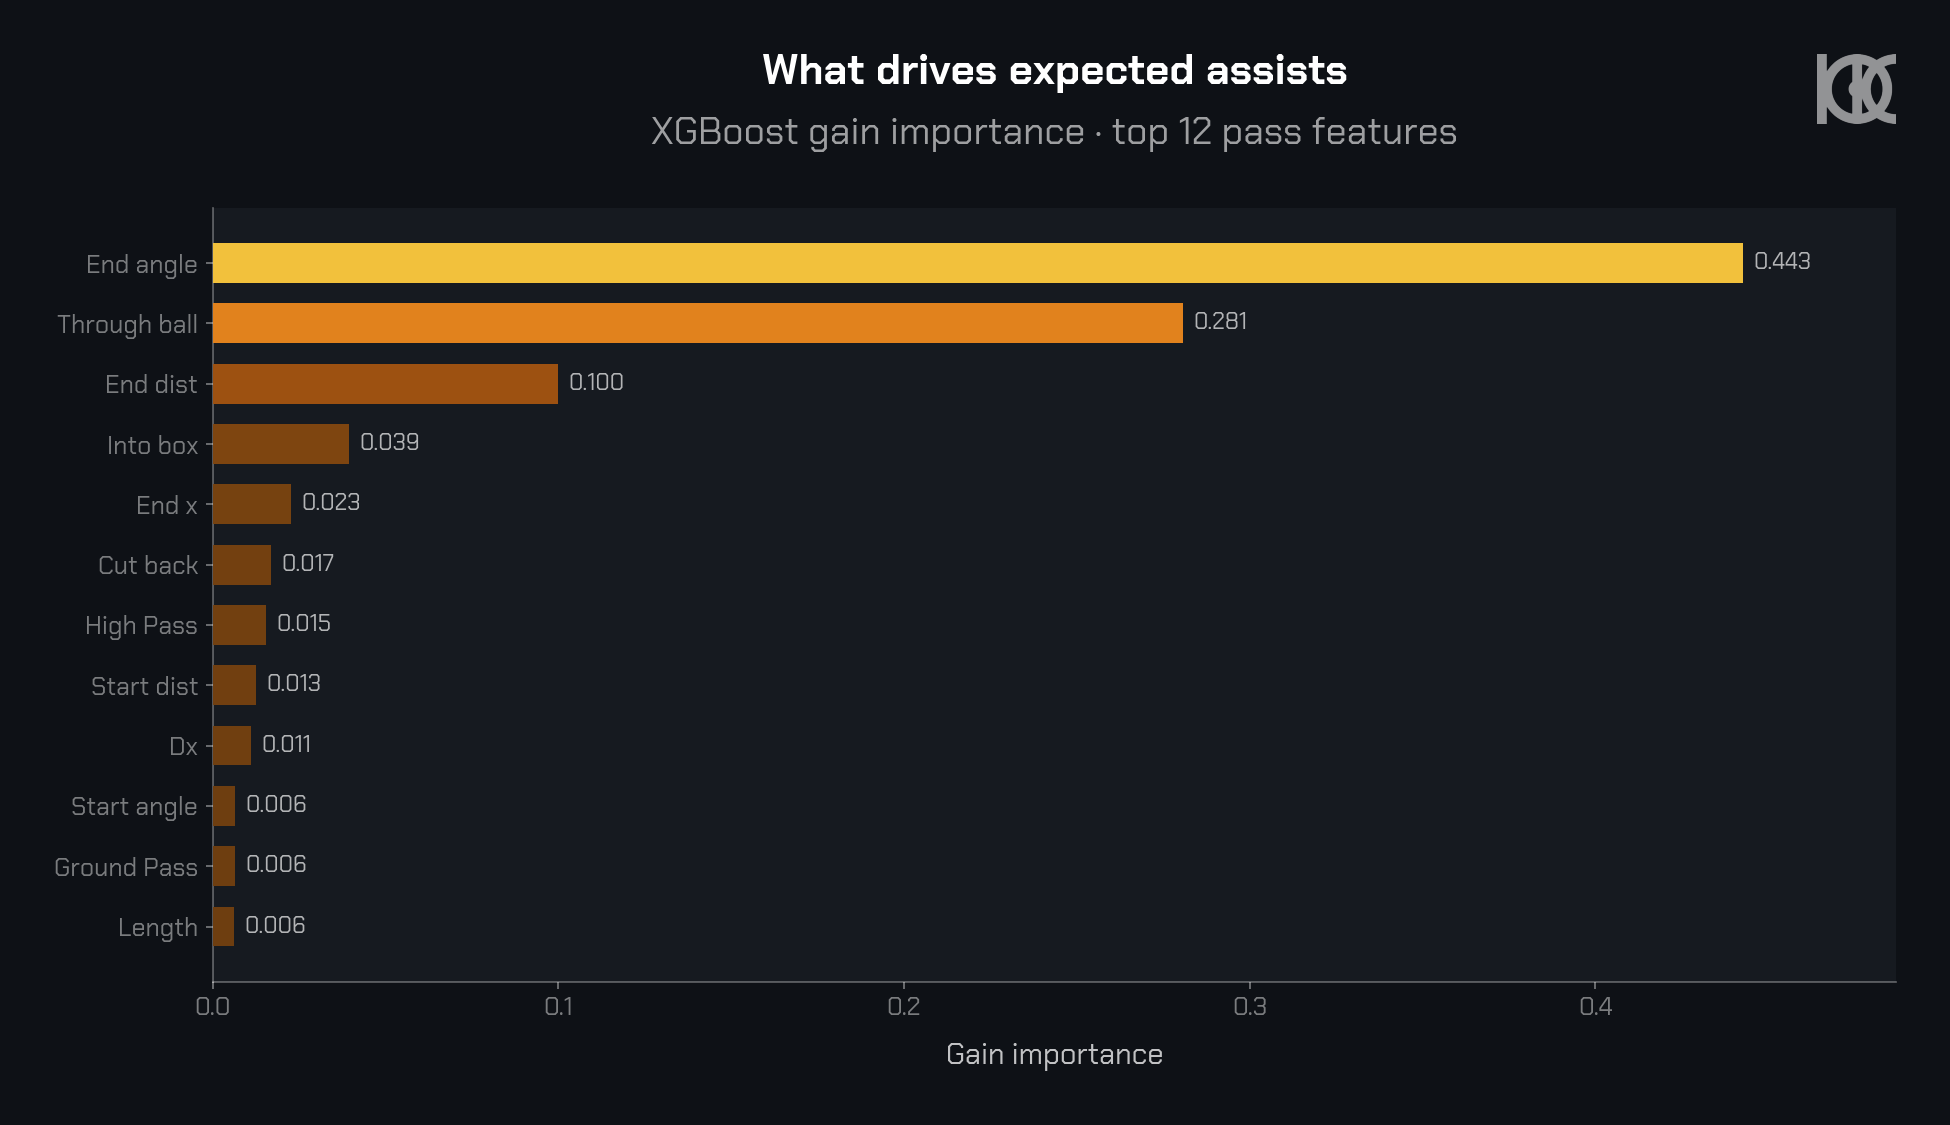

In [9]:
imp = (pd.Series(xgb.feature_importances_, index=feature_cols)
       .sort_values(ascending=False).head(12).iloc[::-1])   # ascending -> largest on top


def _pretty(name):
    name = name.replace("height_", "").replace("body_part_", "").replace("_", " ")
    return name[:1].upper() + name[1:]


fig, ax = plt.subplots(figsize=(13, 7.5))
norm = Normalize(0.0, imp.max())
ax.barh(range(len(imp)), imp.values, height=0.66, zorder=3,
        color=[KICK_SEQ_WARM(norm(v)) for v in imp.values])
ax.set_yticks(range(len(imp)))
ax.set_yticklabels([_pretty(n) for n in imp.index])
ax.set_xlim(0, imp.max())
ax.set_xlabel("Gain importance")
kick_bar_labels(ax, list(range(len(imp))), imp.values, fmt="{:.3f}", orient="h")
kick_title(fig, ax, "What drives expected assists",
           "XGBoost gain importance · top 12 pass features", pitch=False)
plt.show()

Finally we score **every** open-play pass with the deployed XGBoost model. This
`xa` column — an expected-assist value on every ball, whether or not a shot
followed — is what the visualisations below read from.

In [10]:
df["xa"] = np.clip(xgb.predict(X), 0.0, 1.0)

# saved for reuse by sibling notebooks (guarded to a no-op by the render harness)
joblib.dump((xgb, feature_cols), "model_utils/xa_model.pkl")
print(f"Scored {len(df):,} passes · total modelled xA = {df['xa'].sum():,.1f}")

Scored 1,044,467 passes · total modelled xA = 2,725.1


### Where passes create chances — the xA surface

Binning every open-play pass by **where it is delivered** and averaging the
predicted xA in each cell draws the geography of chance creation. The picture is
the classic one: value concentrates at the mouth of the six-yard box and along the
cut-back zones just inside the byline — the places a pass most reliably becomes a
goal. A power-scaled ramp keeps the low-value midfield readable while the danger
zones glow.

[margins  OK ] xa-surface           L=0.360 R=0.360 T=0.360 B=0.360


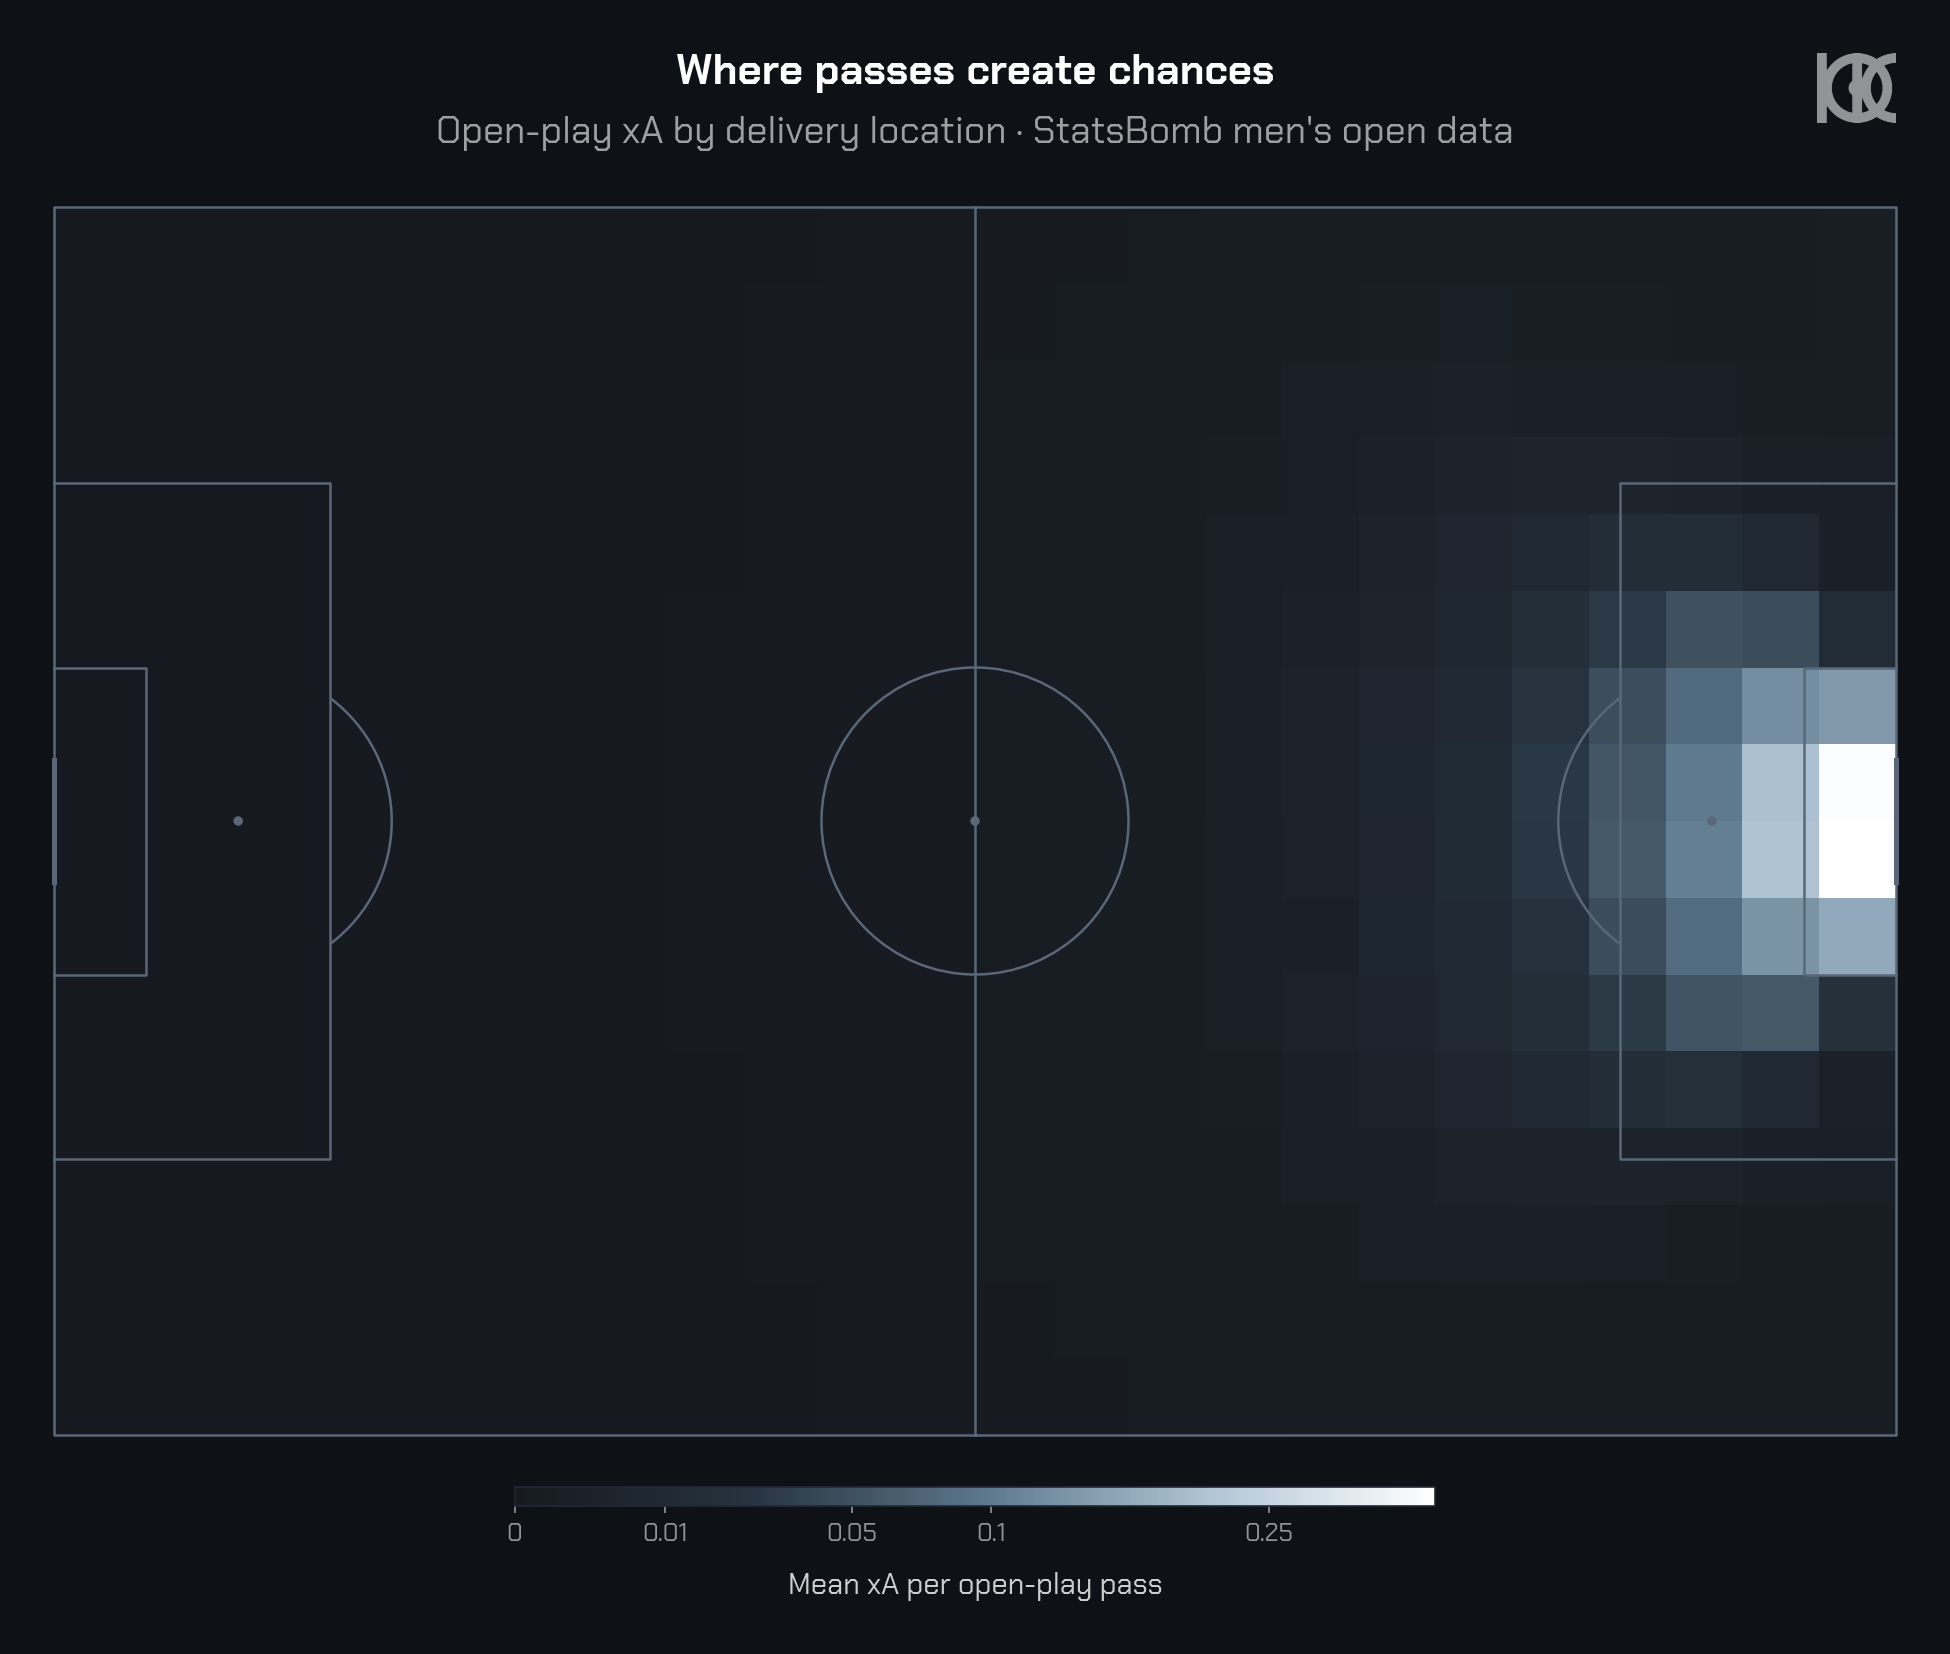

In [11]:
NB, MB, MIN_CNT = 24, 16, 8                        # grid cols(x) x rows(y); min passes per cell
xe = np.linspace(0, PITCH_LENGTH, NB + 1)
ye = np.linspace(0, PITCH_WIDTH, MB + 1)

wsum, _, _ = np.histogram2d(df["end_x"], df["end_y"], bins=[xe, ye], weights=df["xa"])
cnt, _, _ = np.histogram2d(df["end_x"], df["end_y"], bins=[xe, ye])
mean_xa = np.divide(wsum, cnt, out=np.zeros_like(wsum), where=cnt >= MIN_CNT)
Z = mean_xa.T                                      # -> (rows, cols) for pcolormesh(xe, ye, Z)

pitch, fig, ax = draw_kick_pitch(pitch_type="statsbomb", cbar=True, cbar_pos="bottom")
mesh = ax.pcolormesh(xe, ye, Z, cmap=KICK_SEQ,
                     norm=PowerNorm(gamma=0.5, vmin=0.0, vmax=Z.max()), zorder=0.8)
kick_clip(ax)
kick_cbar(fig, ax, mesh, "Mean xA per open-play pass")
kick_title(fig, ax, "Where passes create chances",
           "Open-play xA by delivery location · StatsBomb men's open data", pitch=True)
kick_verify_margins(fig, label="xa-surface")
plt.show()

### A season's creators, on the pitch

To turn xA into a picture of *players*, we sum each creator's open-play xA across a
season and place them as house **checker nodes** at their average passing position
— the same node idiom as the [passing network](passing_network.ipynb). Node **size**
is how many shots they set up (key passes) and node **colour** is their season xA,
so the biggest, brightest chips are a team's chance-creation engines. We use
**Barcelona, La Liga 2015/16** — the season the passing-network notebook builds on.

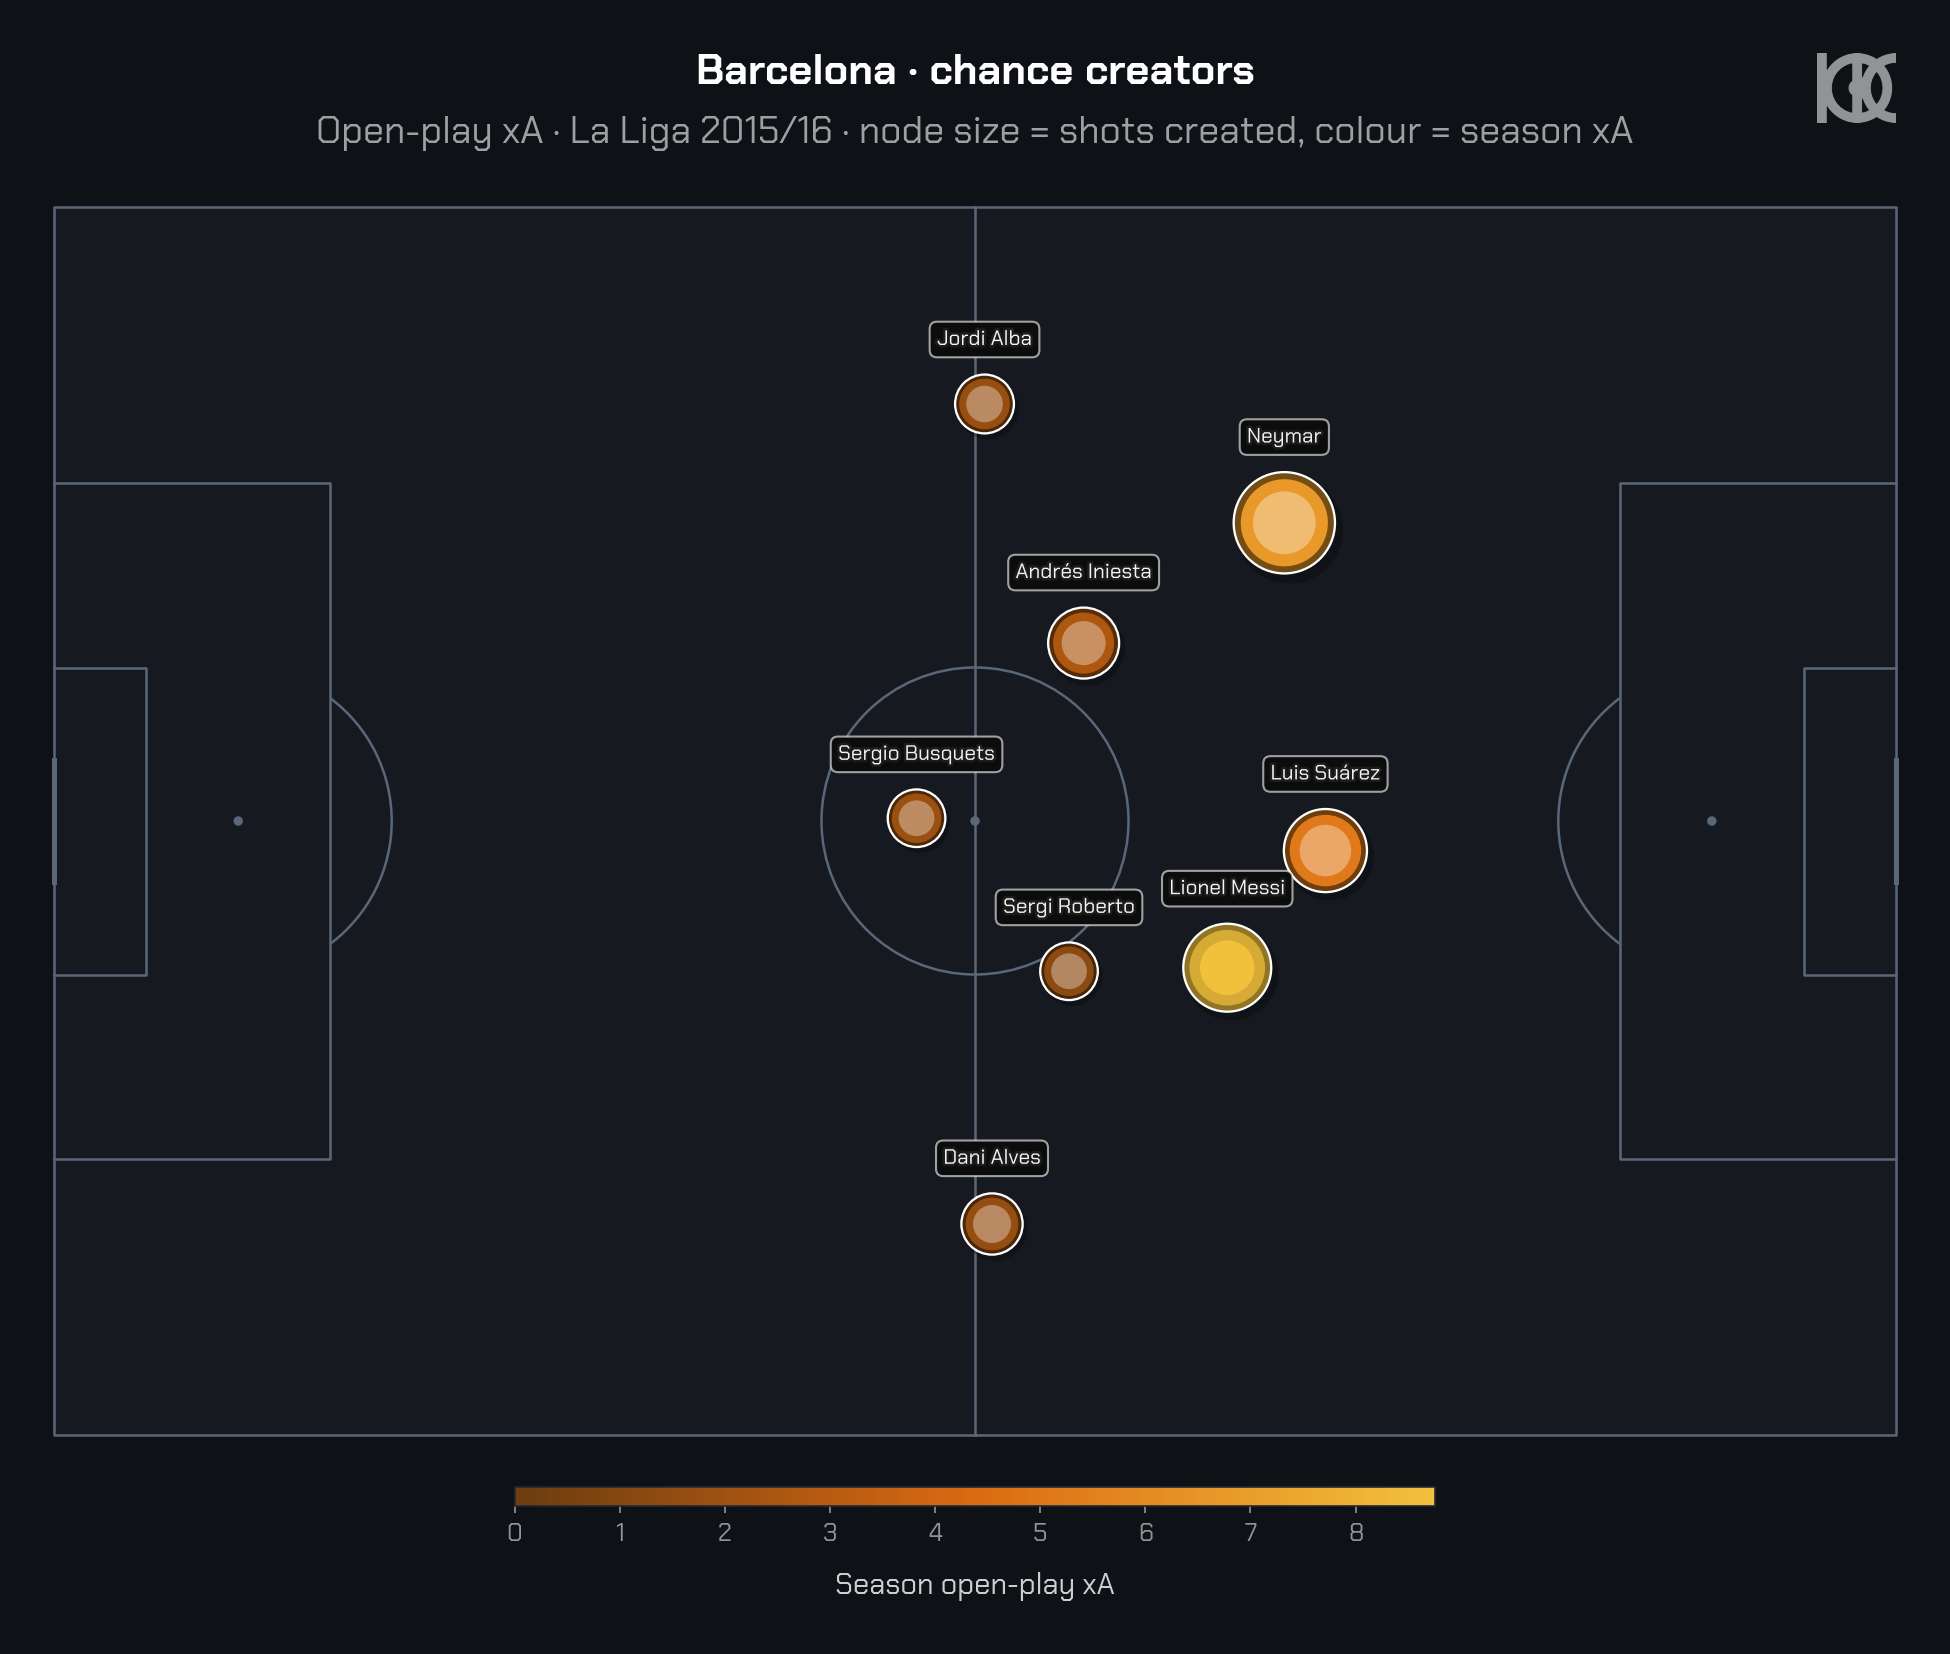

In [12]:
COMP_ID, SEASON_ID, TEAM, SEASON_LABEL = 11, 27, "Barcelona", "La Liga 2015/16"

with open(BASE_DIR / f"matches/{COMP_ID}/{SEASON_ID}.json", encoding="utf-8") as f:
    season_matches = json.load(f)
season_ids = {m["match_id"] for m in season_matches}
barca_ids = {m["match_id"] for m in season_matches
             if TEAM in (m["home_team"]["home_team_name"], m["away_team"]["away_team_name"])}


def load_lineup_file(match_id):
    with open(BASE_DIR / f"lineups/{match_id}.json", encoding="utf-8") as f:
        raw = json.load(f)
    out = []
    for team in raw:
        for p in team["lineup"]:
            out.append((p["player_id"], p.get("player_nickname") or p["player_name"]))
    return out


# short "known as" display names from the season's lineup feeds
name_map = {}
for mid in sorted(season_ids):
    for pid, disp in load_lineup_file(mid):
        name_map.setdefault(pid, disp)


def creator_table(frame):
    # node position = average pass origin (the player's tactical location, exactly
    # as the passing-network notebook places nodes) — this keeps the deep
    # midfielders deep and spreads the board into a legible shape.
    g = frame.groupby(["player_id", "player_name"]).agg(
        xa=("xa", "sum"), key_passes=("is_key", "sum"), assists=("goal_assist", "sum"),
        mx=("start_x", "mean"), my=("start_y", "mean"), n=("xa", "size"),
    ).reset_index()
    g["disp"] = g["player_id"].map(name_map).fillna(g["player_name"])
    return g.sort_values(["xa", "player_id"], ascending=[False, True])


barca = df[(df["match_id"].isin(barca_ids)) & (df["team_name"] == TEAM)]
top = creator_table(barca).head(8).reset_index(drop=True)

pitch, fig, ax = draw_kick_pitch(pitch_type="statsbomb", cbar=True, cbar_pos="bottom")
norm = Normalize(vmin=0.0, vmax=max(top["xa"].max(), 1e-6))
kp_max = max(top["key_passes"].max(), 1)
R_MIN, R_MAX = 1.6, 3.3
for r in top.itertuples():
    radius = R_MIN + (R_MAX - R_MIN) * (r.key_passes / kp_max)
    kick_checker(ax, r.mx, r.my, radius, KICK_SEQ_WARM(norm(r.xa)),
                 name=r.disp, name_size=10)
sm = ScalarMappable(norm=norm, cmap=KICK_SEQ_WARM); sm.set_array([])
kick_cbar(fig, ax, sm, "Season open-play xA")
kick_title(fig, ax, f"{TEAM} · chance creators",
           f"Open-play xA · {SEASON_LABEL} · node size = shots created, colour = season xA", pitch=True)
plt.show()

### One match, on the ball — the Clásico's chance creation

Zooming all the way in, we draw **every shot-creating pass** one team played in a
single match: each an arrow from where it was played to where it arrived, coloured
by its xA. The marquee fixture is the one the passing-network notebook also uses —
the **Bernabéu Clásico, Real Madrid 0–4 Barcelona** — and Barcelona's open-play
creation maps straight onto the scoreline. A bright dot marks a pass that became a
goal assist; the annotation names the match's busiest creator.

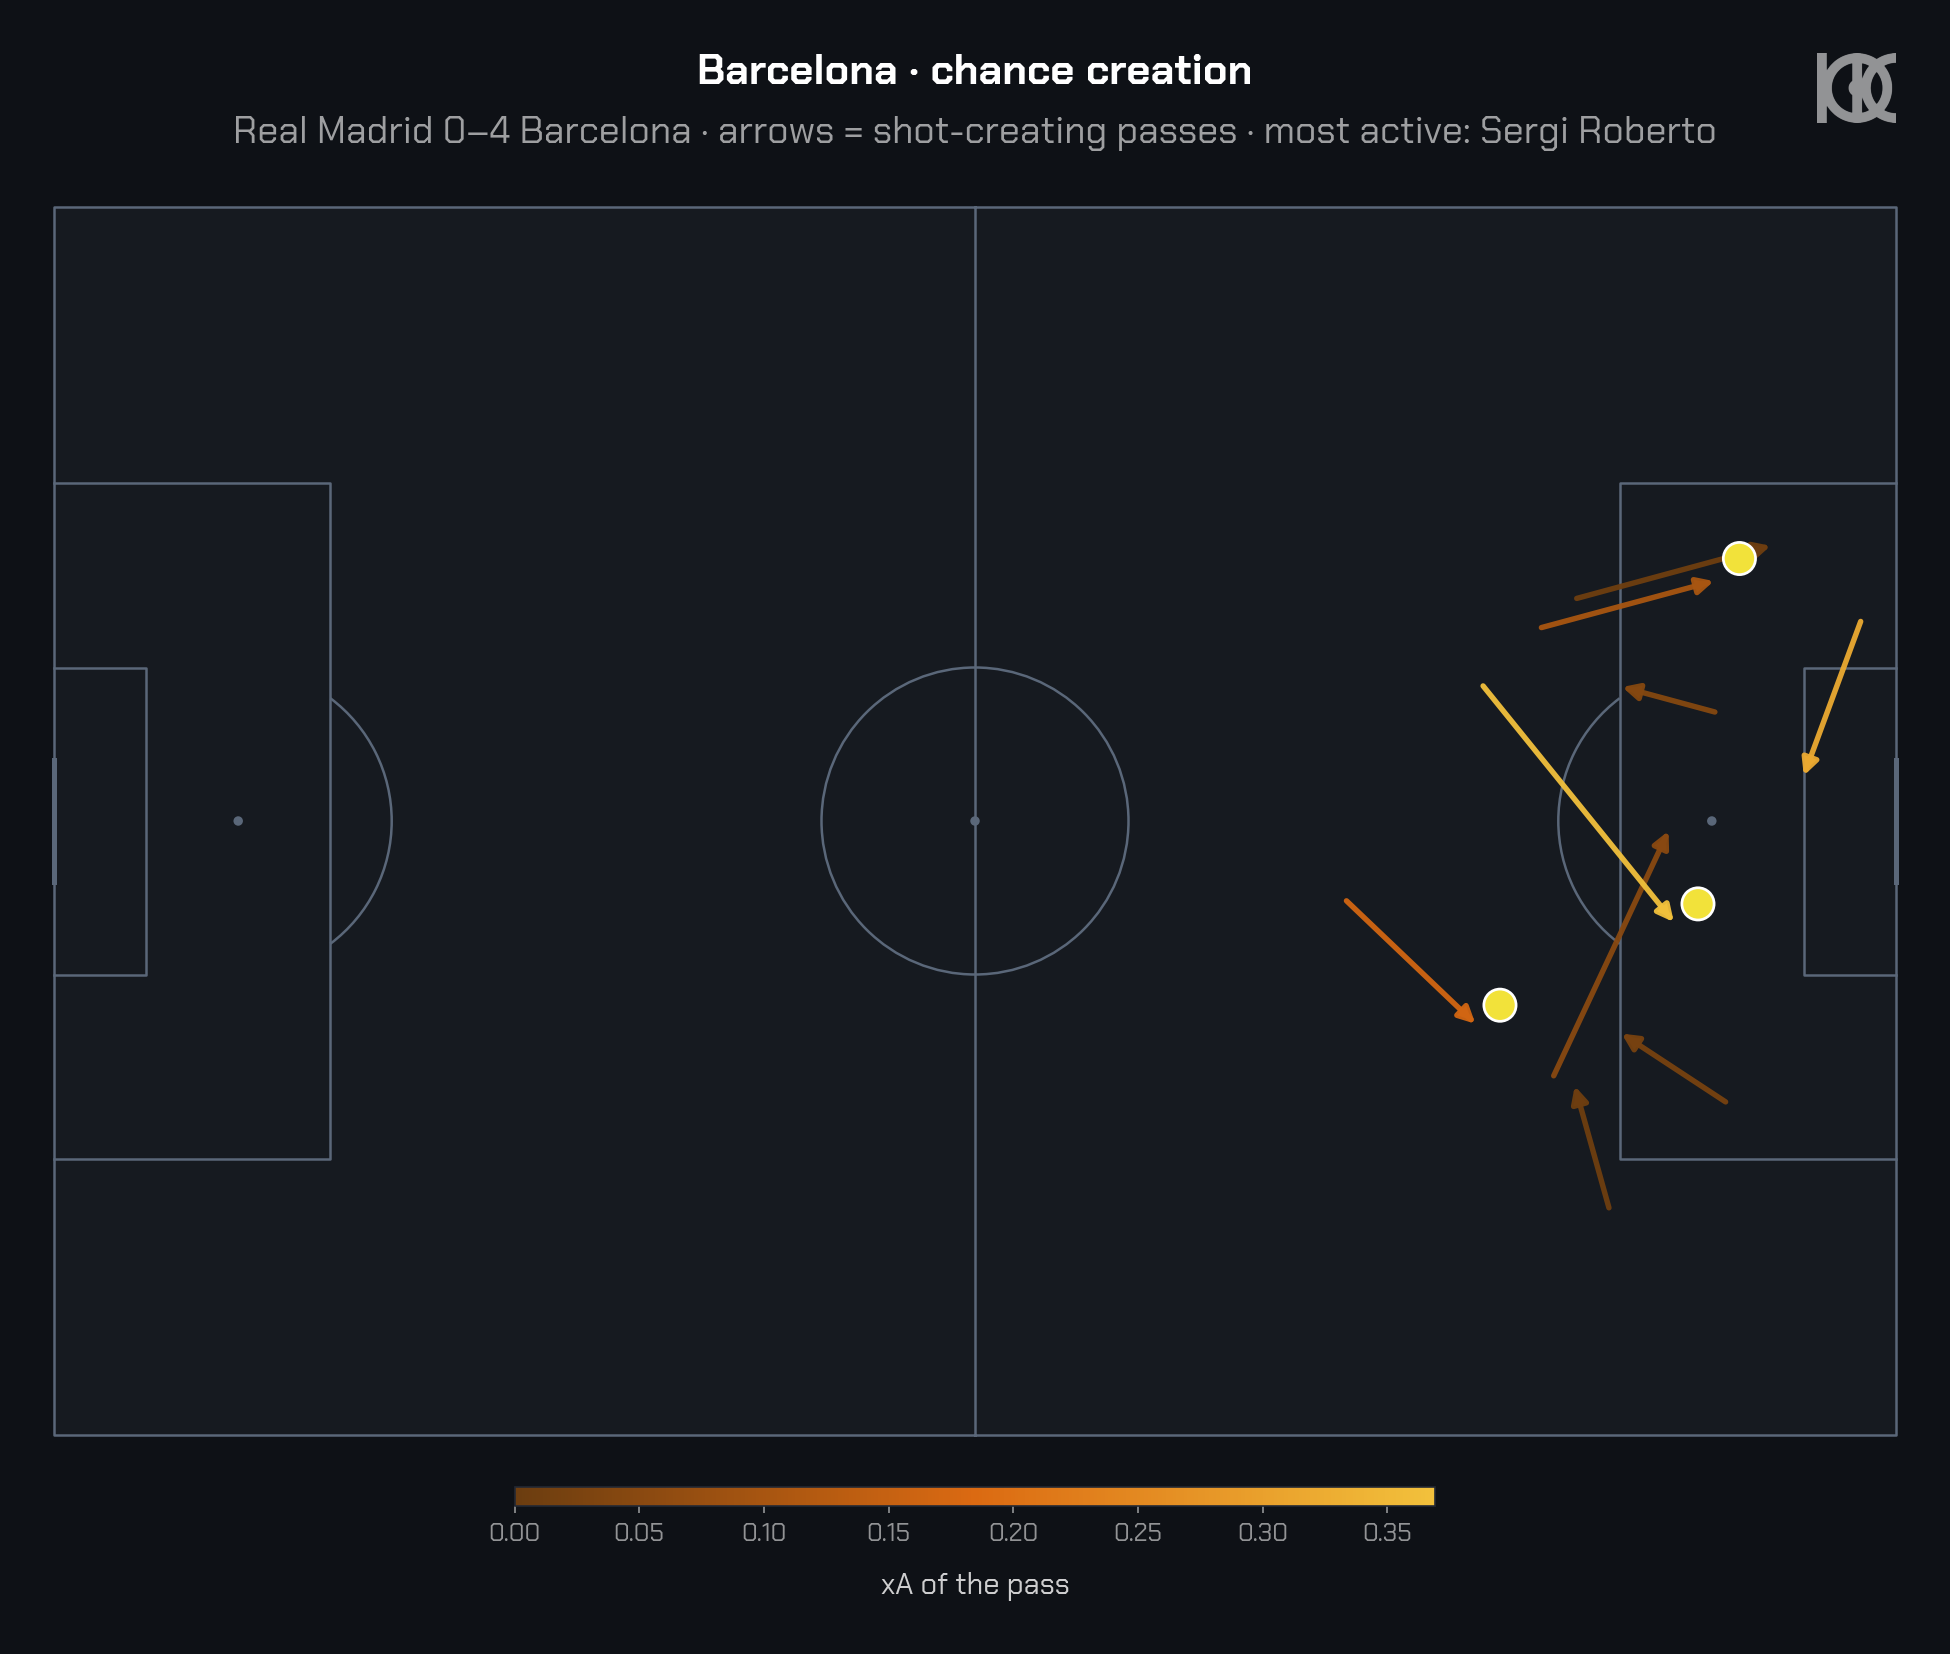

In [13]:
CLASICO_ID = 266424

match = df[(df["match_id"] == CLASICO_ID) & (df["team_name"] == TEAM)]
keys = match[match["is_key"]].sort_values("xa")

# the match's busiest open-play creator, for the annotation (explicit tie-breaks)
kp_rank = (keys.groupby("player_id")
           .agg(k=("is_key", "size"), xa=("xa", "sum"))
           .reset_index()
           .sort_values(["k", "xa", "player_id"], ascending=[False, False, True]))
top_disp = name_map.get(kp_rank["player_id"].iloc[0], "—") if len(kp_rank) else "—"

pitch, fig, ax = draw_kick_pitch(pitch_type="statsbomb", cbar=True, cbar_pos="bottom")
norm = Normalize(vmin=0.0, vmax=max(keys["xa"].max(), 1e-6))
for r in keys.itertuples():
    ax.annotate("", xy=(r.end_x, r.end_y), xytext=(r.start_x, r.start_y),
                arrowprops=dict(arrowstyle="-|>", color=KICK_SEQ_WARM(norm(r.xa)),
                                lw=2.6, alpha=0.95, shrinkA=0, shrinkB=2), zorder=6)
    if r.goal_assist:
        kick_node_icon(ax, r.end_x, r.end_y, r=1.5, icon="goal")
kick_clip(ax)
sm = ScalarMappable(norm=norm, cmap=KICK_SEQ_WARM); sm.set_array([])
kick_cbar(fig, ax, sm, "xA of the pass")
kick_title(fig, ax, f"{TEAM} · chance creation",
           f"Real Madrid 0–4 Barcelona · arrows = shot-creating passes · most active: {top_disp}",
           pitch=True)
plt.show()

### Expected vs actual — who is creating, who is finishing

xA's headline use is separating creation from conversion. We put each player's
**xA per 90 minutes** on one axis and their **actual assists per 90** on the other,
so an impact substitute and an ever-present are judged on equal terms — and, because
we divide by minutes played rather than plotting raw counts, the points spread
naturally instead of stacking on the integer assist totals. The diagonal is the
break-even line: players **above** it saw their chances converted more often than
the model expected (well-finished, or fortunate); players **below** created more
than the scoreline credits them for. We use the full **La Liga 2015/16** field at a
minimum of 900 minutes, and label the biggest over/under-performers plus the
standout creators.

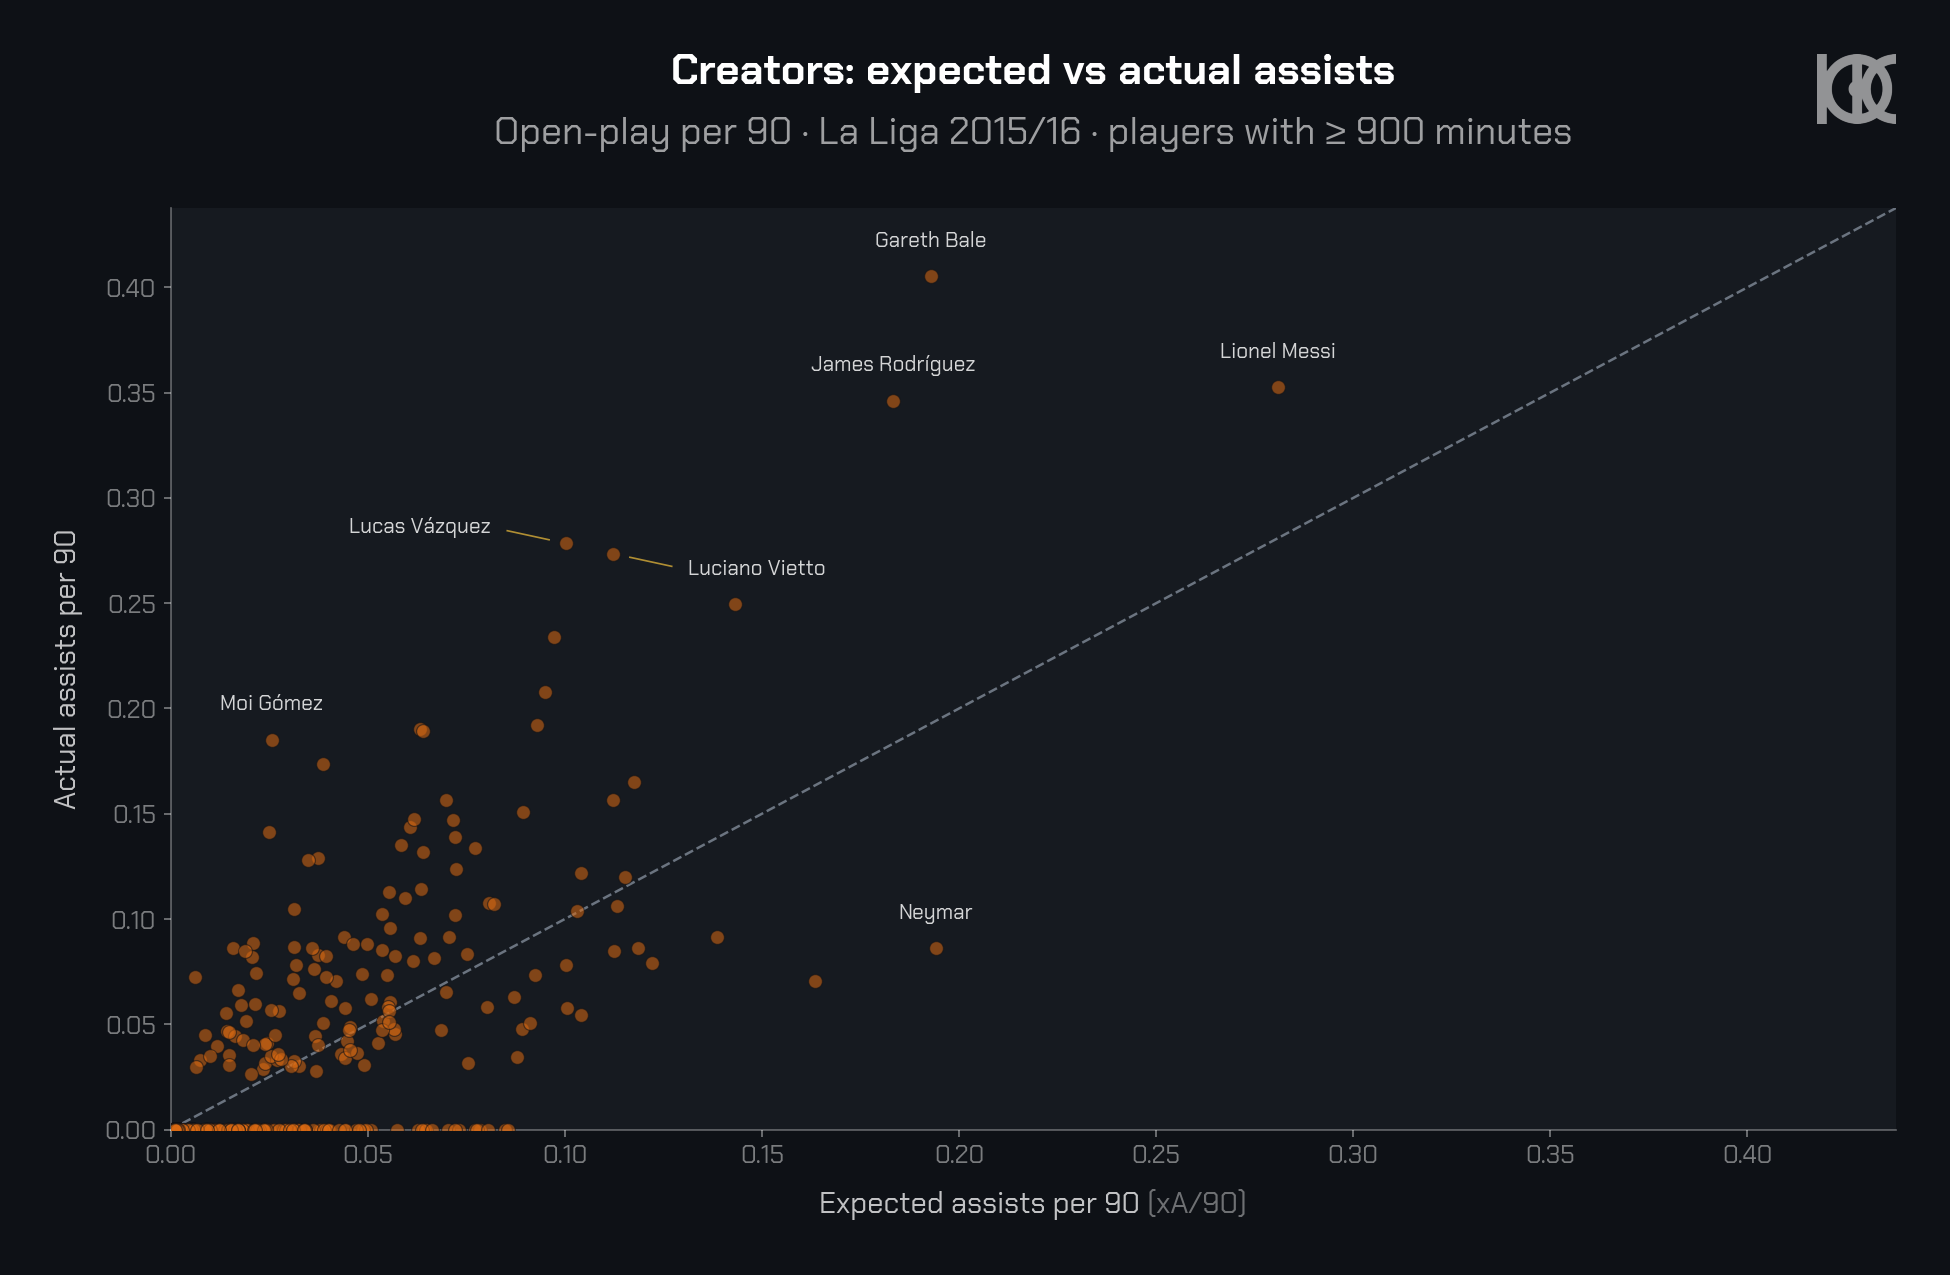

In [14]:
MIN_MINUTES = 900

# per 90 needs minutes played: reconstruct each player's on-pitch time from every
# season match's Starting XI, substitutions and red cards (the same appearance
# logic the passing-network notebook uses), then sum across the season.
def load_match_minutes(match_id):
    with open(BASE_DIR / f"events/{match_id}.json", encoding="utf-8") as f:
        ev = json.load(f)
    end = max(e.get("minute", 0) * 60 + e.get("second", 0) for e in ev) / 60.0
    starts, ends = {}, {}
    for e in ev:
        t = e["type"]["name"]
        if t == "Starting XI":
            for p in e["tactics"]["lineup"]:
                starts[p["player"]["id"]] = 0.0
        elif t == "Substitution":
            m = e["minute"] + e["second"] / 60.0
            ends[e["player"]["id"]] = m
            starts[e["substitution"]["replacement"]["id"]] = m
    for e in ev:                                          # a red card ends a game early
        card = (e.get("bad_behaviour") or {}).get("card") or (e.get("foul_committed") or {}).get("card") or {}
        if card.get("name") in ("Red Card", "Second Yellow") and e.get("player"):
            pid = e["player"]["id"]
            ends[pid] = min(ends.get(pid, end), e["minute"] + e["second"] / 60.0)
    return {pid: max(0.0, ends.get(pid, end) - s) for pid, s in starts.items()}


player_minutes = {}
with Pool(cpu_count()) as pool:
    for mins in pool.imap(load_match_minutes, sorted(season_ids)):    # sorted -> reproducible sum
        for pid, m in mins.items():
            player_minutes[pid] = player_minutes.get(pid, 0.0) + m

season = df[df["match_id"].isin(season_ids)]
players = season.groupby(["player_id", "player_name"]).agg(
    xa=("xa", "sum"), assists=("goal_assist", "sum"),
).reset_index()
players["minutes"] = players["player_id"].map(player_minutes)
players = players[players["minutes"] >= MIN_MINUTES].copy()
players["xa90"] = players["xa"] * 90.0 / players["minutes"]
players["a90"] = players["assists"] * 90.0 / players["minutes"]
players["disp"] = players["player_id"].map(name_map).fillna(players["player_name"])
players["resid"] = players["a90"] - players["xa90"]

fig, ax = plt.subplots(figsize=(13, 8.5))
ax.scatter(players["xa90"], players["a90"], s=44, color=KICK["home"],
           alpha=0.55, edgecolor=KICK["figure"], linewidth=0.6, zorder=3)
lim = max(players["xa90"].max(), players["a90"].max()) * 1.08
ax.plot([0, lim], [0, lim], color=KICK["muted"], ls="--", lw=1.2, zorder=1)
ax.set_xlim(0, lim); ax.set_ylim(0, lim)
ax.set_xlabel("Expected assists per 90 (xA/90)")
ax.set_ylabel("Actual assists per 90")

kick_title(fig, ax, "Creators: expected vs actual assists",
           f"Open-play per 90 · {SEASON_LABEL} · players with ≥ {MIN_MINUTES} minutes", pitch=False)

# name (a) the biggest over/under-performers by residual, (b) the top creators by
# xA/90 — the prominent right-hand points, including high-creation under-performers —
# and (c) the most assists/90, so no standout dot is left unlabelled
by_resid = players.reindex(players["resid"].abs().sort_values(ascending=False).index).head(5)
labelled = pd.concat([by_resid, players.nlargest(3, "xa90"), players.nlargest(1, "a90")]
                     ).drop_duplicates(subset="player_id")
kick_smart_labels(ax, labelled[["xa90", "a90"]].to_numpy(), labelled["disp"].tolist())
plt.show()

### From one metric to a creation model

This notebook builds **open-play xA** from the ground up — reusing the xG model to
value the shot a pass creates, then learning that value from the pass alone — and
reads it back out as a chance-creation surface, a season leaderboard, a single
creator's fingerprint, and an expected-vs-actual scorecard. The same building
blocks extend naturally:

| Direction | What it adds |
| --- | --- |
| **xG + xA together** | attribute each chance to *both* its finisher (xG) and its creator (xA) — the full picture of who makes and who takes chances. |
| **Per-90 & possession-adjusted** | normalise season xA by minutes played and team volume, so a creator in a low-possession side is not penalised for touches they never get. |
| **Set-piece xA** | a separate model for corners and free-kicks, deliberately excluded here — dead-ball creation follows very different geometry. |
| **Deeper in the chain** | value the pass *before* the assist (the "second assist"), tracing chance creation back up the possession, much as [xT](xT.ipynb) already values every link. |

Each reuses the exact pass table and scoring path above; only the grouping and the
target window change.